In [3]:
# WeatherAPI.com quick notebook test (Current + 7-day forecast)
# Riviera CC ZIP: 90272

import requests
from urllib.parse import urljoin
from pprint import pprint

BASE_URL = "http://api.weatherapi.com/v1/"

class WeatherAPIError(RuntimeError):
    pass

def weatherapi_get(endpoint: str, *, api_key: str, q: str, **params) -> dict:
    url = urljoin(BASE_URL, endpoint.lstrip("/"))
    full_params = {"key": api_key, "q": q, **params}

    r = requests.get(url, params=full_params, timeout=20)
    try:
        data = r.json()
    except Exception as e:
        raise WeatherAPIError(f"Non-JSON response (status={r.status_code}): {r.text[:300]}") from e

    if r.status_code != 200:
        msg = data.get("error", {}).get("message") or str(data)
        raise WeatherAPIError(f"WeatherAPI error (status={r.status_code}): {msg}")

    return data

def get_current(api_key: str, q: str, *, aqi: bool = False, lang: str | None = None) -> dict:
    params = {"aqi": "yes" if aqi else "no"}
    if lang:
        params["lang"] = lang
    return weatherapi_get("current.json", api_key=api_key, q=q, **params)

def get_forecast(
    api_key: str,
    q: str,
    *,
    days: int = 7,
    aqi: bool = False,
    alerts: bool = False,
    lang: str | None = None,
) -> dict:
    if not (1 <= days <= 14):
        raise ValueError("days must be between 1 and 14")

    params = {
        "days": days,
        "aqi": "yes" if aqi else "no",
        "alerts": "yes" if alerts else "no",
    }
    if lang:
        params["lang"] = lang
    return weatherapi_get("forecast.json", api_key=api_key, q=q, **params)

def summarize_forecast(fx: dict) -> dict:
    loc = fx["location"]
    cur = fx.get("current", {})
    out = {
        "place": f'{loc.get("name")}, {loc.get("region")} ({loc.get("country")})',
        "localtime": loc.get("localtime"),
        "current": {
            "temp_f": cur.get("temp_f"),
            "feelslike_f": cur.get("feelslike_f"),
            "wind_mph": cur.get("wind_mph"),
            "wind_dir": cur.get("wind_dir"),
            "humidity": cur.get("humidity"),
            "condition": (cur.get("condition") or {}).get("text"),
        },
        "daily": [],
    }
    for d in fx["forecast"]["forecastday"]:
        day = d["day"]
        out["daily"].append({
            "date": d["date"],
            "max_f": day.get("maxtemp_f"),
            "min_f": day.get("mintemp_f"),
            "wind_mph": day.get("maxwind_mph"),
            "rain_in": day.get("totalprecip_in"),
            "chance_rain": day.get("daily_chance_of_rain"),
            "condition": (day.get("condition") or {}).get("text"),
        })
    return out

# ---- set your key here ----
API_KEY = "37a2c5c67db34e6e970210615261702"

# Riviera CC ZIP
Q = "90272"

# Current
cur = get_current(API_KEY, Q, aqi=False)
print("Current:", cur["location"]["name"], cur["current"]["temp_f"], "F |", cur["current"]["condition"]["text"])

# Forecast
fx = get_forecast(API_KEY, Q, days=7, aqi=False, alerts=False)
summary = summarize_forecast(fx)

print("\nSummary:")
pprint(summary)

print("\nDaily rows only:")
pprint(summary["daily"])


Current: Pacific Palisades 50.4 F | Clear

Summary:
{'current': {'condition': 'Clear',
             'feelslike_f': 46.7,
             'humidity': 63,
             'temp_f': 50.4,
             'wind_dir': 'W',
             'wind_mph': 9.2},
 'daily': [{'chance_rain': 89,
            'condition': 'Moderate rain',
            'date': '2026-02-18',
            'max_f': 60.4,
            'min_f': 46.8,
            'rain_in': 0.31,
            'wind_mph': 29.8},
           {'chance_rain': 80,
            'condition': 'Moderate rain',
            'date': '2026-02-19',
            'max_f': 55.6,
            'min_f': 42.3,
            'rain_in': 0.54,
            'wind_mph': 17.9},
           {'chance_rain': 0,
            'condition': 'Cloudy ',
            'date': '2026-02-20',
            'max_f': 52.7,
            'min_f': 41.5,
            'rain_in': 0.0,
            'wind_mph': 8.9},
           {'chance_rain': 0,
            'condition': 'Fog',
            'date': '2026-02-21',
          

In [5]:
import requests
import pandas as pd
from urllib.parse import urljoin

BASE_URL = "http://api.weatherapi.com/v1/"

class WeatherAPIError(RuntimeError):
    pass

def _get_json(endpoint: str, params: dict, timeout: int = 20) -> dict:
    url = urljoin(BASE_URL, endpoint.lstrip("/"))
    r = requests.get(url, params=params, timeout=timeout)
    try:
        data = r.json()
    except Exception as e:
        raise WeatherAPIError(f"Non-JSON response (status={r.status_code}): {r.text[:300]}") from e
    if r.status_code != 200:
        msg = data.get("error", {}).get("message") or str(data)
        raise WeatherAPIError(f"WeatherAPI error (status={r.status_code}): {msg}")
    return data

def forecast_hourly_between(api_key: str, q: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Pull ONE forecast request (days=1..14) and return hourly rows between start_date and end_date inclusive.
    Dates: 'YYYY-MM-DD'
    """
    start = pd.to_datetime(start_date).date()
    end = pd.to_datetime(end_date).date()
    if end < start:
        raise ValueError("end_date must be >= start_date")

    # WeatherAPI forecast uses days count starting from "today"
    # We'll request enough days to cover end_date, but cap at 14.
    today = pd.Timestamp.now().date()
    days_needed = (end - today).days + 1
    if days_needed < 1:
        raise ValueError("These dates are not in the forecast window (they're in the past). Use history.json for past dates.")
    if days_needed > 14:
        raise ValueError("End date is beyond 14-day forecast window. Use future.json (plan-dependent) or another provider.")

    data = _get_json(
        "forecast.json",
        params={
            "key": api_key,
            "q": q,
            "days": int(days_needed),
            "aqi": "no",
            "alerts": "no",
        },
    )

    loc = data["location"]
    rows = []
    for fd in data["forecast"]["forecastday"]:
        d = pd.to_datetime(fd["date"]).date()
        if d < start or d > end:
            continue
        for h in fd["hour"]:
            rows.append({
                "dt_local": h.get("time"),
                "date": fd.get("date"),
                "tz_id": loc.get("tz_id"),
                "name": loc.get("name"),
                "region": loc.get("region"),
                "country": loc.get("country"),
                "lat": loc.get("lat"),
                "lon": loc.get("lon"),

                "temp_f": h.get("temp_f"),
                "feelslike_f": h.get("feelslike_f"),
                "humidity": h.get("humidity"),
                "wind_mph": h.get("wind_mph"),
                "wind_dir": h.get("wind_dir"),
                "gust_mph": h.get("gust_mph"),
                "pressure_in": h.get("pressure_in"),
                "precip_in": h.get("precip_in"),
                "chance_of_rain": h.get("chance_of_rain"),
                "cloud": h.get("cloud"),
                "vis_miles": h.get("vis_miles"),
                "uv": h.get("uv"),
                "condition": (h.get("condition") or {}).get("text"),
            })

    df = pd.DataFrame(rows)
    df["dt_local"] = pd.to_datetime(df["dt_local"], errors="coerce")
    df = df.sort_values("dt_local").reset_index(drop=True)
    return df

# ---- run it ----
API_KEY = "37a2c5c67db34e6e970210615261702"
Q = "90272"

df_hourly = forecast_hourly_between(API_KEY, Q, "2026-02-19", "2026-02-22")
df_hourly


,dt_local,date,tz_id,name,region,country,lat,lon,temp_f,feelslike_f,...,wind_mph,wind_dir,gust_mph,pressure_in,precip_in,chance_of_rain,cloud,vis_miles,uv,condition
0,2026-02-19 00:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,47.2,46.7,...,7.2,W,9.4,30.01,0.0,0,0,6.0,0.0,Clear
1,2026-02-19 01:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,46.4,45.3,...,8.1,WNW,10.8,30.01,0.0,0,0,6.0,0.0,Clear
2,2026-02-19 02:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,45.8,44.4,...,8.9,WNW,12.1,30.00,0.0,0,0,6.0,0.0,Clear
3,2026-02-19 03:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,44.8,43.0,...,9.2,WNW,12.7,29.97,0.0,0,0,6.0,0.0,Clear
4,2026-02-19 04:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,44.0,42.1,...,7.8,W,11.1,29.98,0.0,0,0,6.0,0.0,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2026-02-22 19:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,62.3,62.4,...,3.4,W,6.4,30.16,0.0,0,4,6.0,0.0,Clear
92,2026-02-22 20:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,61.9,61.9,...,3.4,NW,6.8,30.18,0.0,0,65,6.0,0.0,Cloudy
93,2026-02-22 21:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,61.1,61.1,...,4.3,NNW,8.9,30.20,0.0,0,0,6.0,0.0,Clear
94,2026-02-22 22:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,60.3,60.3,...,4.5,NNW,9.4,30.19,0.0,0,0,6.0,0.0,Clear


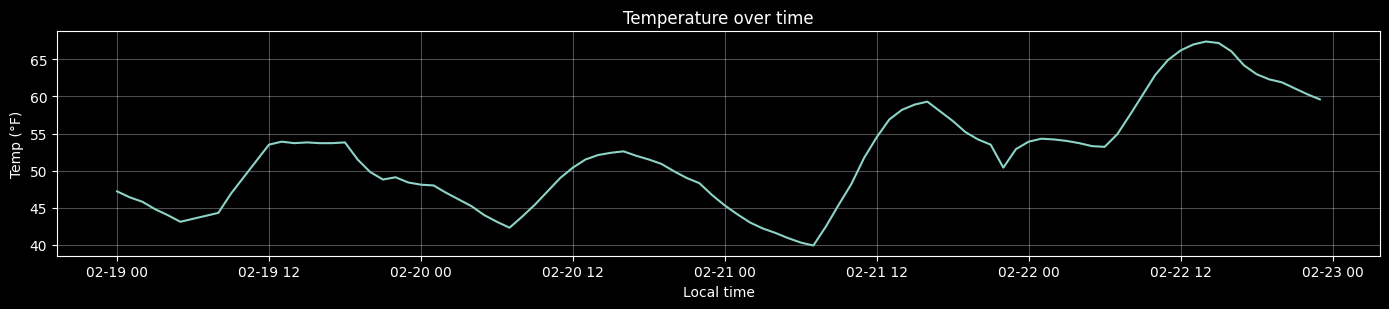

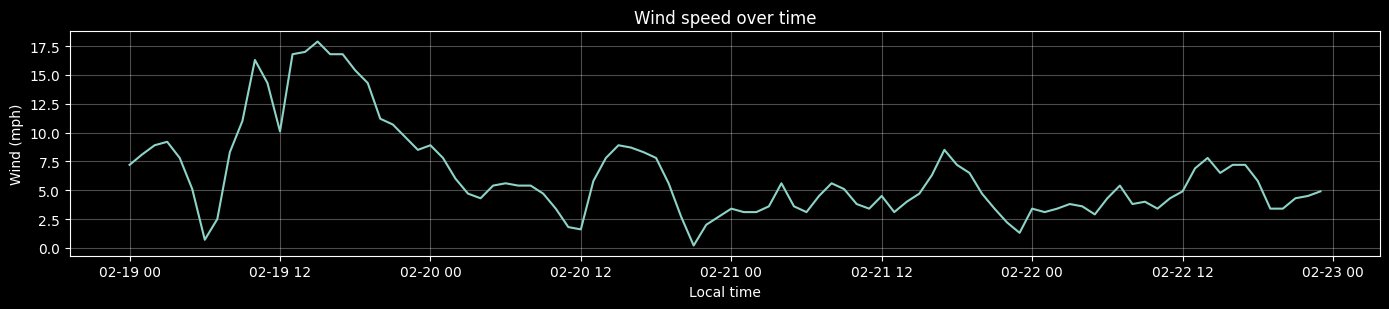

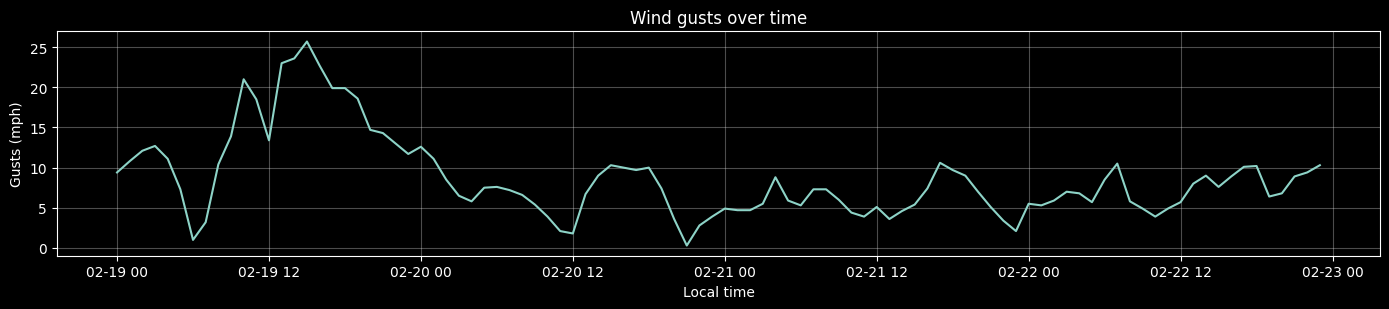

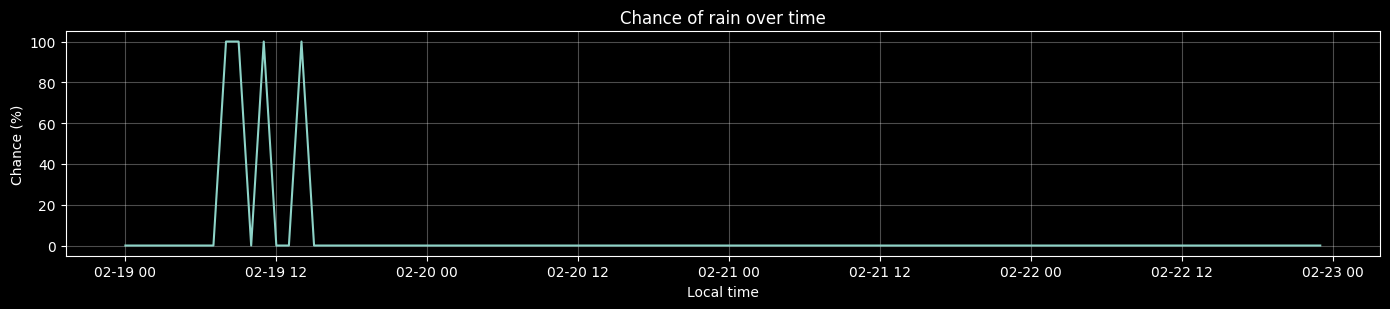

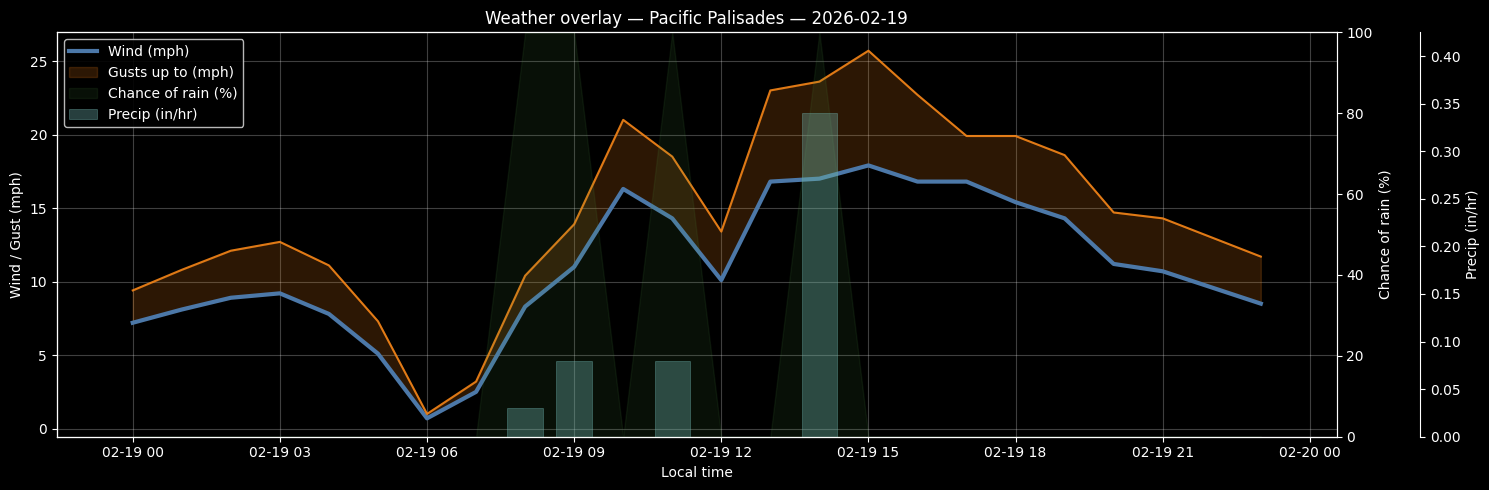

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# If your dataframe has a different name, change df_hourly below.
dfp = df_hourly.copy()

# Clean + sort
dfp["dt_local"] = pd.to_datetime(dfp["dt_local"], errors="coerce")
dfp = dfp.dropna(subset=["dt_local"]).sort_values("dt_local")

# Force numeric (WeatherAPI sometimes returns strings)
for c in ["temp_f", "wind_mph", "gust_mph", "chance_of_rain"]:
    if c in dfp.columns:
        dfp[c] = pd.to_numeric(dfp[c], errors="coerce")

def line_chart(ycol: str, ylabel: str, title: str):
    if ycol not in dfp.columns:
        raise KeyError(f"Column '{ycol}' not found. Available: {list(dfp.columns)}")

    fig, ax = plt.subplots(figsize=(14, 3.2))
    ax.plot(dfp["dt_local"], dfp[ycol])
    ax.set_title(title)
    ax.set_xlabel("Local time")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

line_chart("temp_f", "Temp (°F)", "Temperature over time")
line_chart("wind_mph", "Wind (mph)", "Wind speed over time")
line_chart("gust_mph", "Gusts (mph)", "Wind gusts over time")
line_chart("chance_of_rain", "Chance (%)", "Chance of rain over time")


def plot_day_wind_rain_precip(dfp: pd.DataFrame, day: str):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    # Ensure numeric
    needed = ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]
    for c in needed:
        if c not in d.columns:
            raise KeyError(f"Missing column '{c}'. Available: {list(d.columns)}")
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(lower=0, upper=100)
    precip = d["precip_in"].clip(lower=0)

    # High-contrast palette
    c_wind = "#4C78A8"   # blue
    c_gust = "#F58518"   # orange
    c_rain = "#54A24B"   # green
    c_prec = "#72B7B2"   # teal

    fig, ax_wind = plt.subplots(figsize=(15, 5))

    # --- WIND (hero line) ---
    ax_wind.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)

    # --- GUST band (wind -> gust) + outline for readability ---
    ax_wind.fill_between(
        x, wind, gust,
        where=(gust >= wind),
        interpolate=True,
        color=c_gust,
        alpha=0.18,
        label="Gusts up to (mph)",
        zorder=4,
    )
    # Outline the gust top so the band edge is visible
    ax_wind.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)

    ax_wind.set_ylabel("Wind / Gust (mph)")
    ax_wind.set_xlabel("Local time")
    ax_wind.grid(True, alpha=0.25, zorder=0)

    # --- Chance of rain (%) as light area on right axis ---
    ax_rain = ax_wind.twinx()
    ax_rain.fill_between(
        x, 0, rain,
        color=c_rain,
        alpha=0.10,           # keep it subtle so it doesn't muddy the plot
        label="Chance of rain (%)",
        zorder=1,
    )
    ax_rain.set_ylim(0, 100)
    ax_rain.set_ylabel("Chance of rain (%)")

    # --- Precip (in/hr) as bars on a second right axis (offset outward) ---
    ax_prec = ax_wind.twinx()
    ax_prec.spines["right"].set_position(("outward", 60))

    # Width tuned for hourly timestamps (matplotlib uses days as units)
    bar_width = 0.03
    ax_prec.bar(
        x, precip,
        width=bar_width,
        color=c_prec,
        alpha=0.35,
        edgecolor=c_prec,
        linewidth=0.7,
        label="Precip (in/hr)",
        zorder=2,
    )

    # Set a sensible precip axis max so tiny bars are still visible
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax_prec.set_ylim(0, max(0.05, pmax * 1.25))
    ax_prec.set_ylabel("Precip (in/hr)")

    # Title
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    ax_wind.set_title(f"Weather overlay{title_loc} — {day}")

    # Combined legend
    handles, labels = [], []
    for ax in (ax_wind, ax_rain, ax_prec):
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax_wind.legend(handles, labels, loc="upper left", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Example:
plot_day_wind_rain_precip(dfp, "2026-02-19")


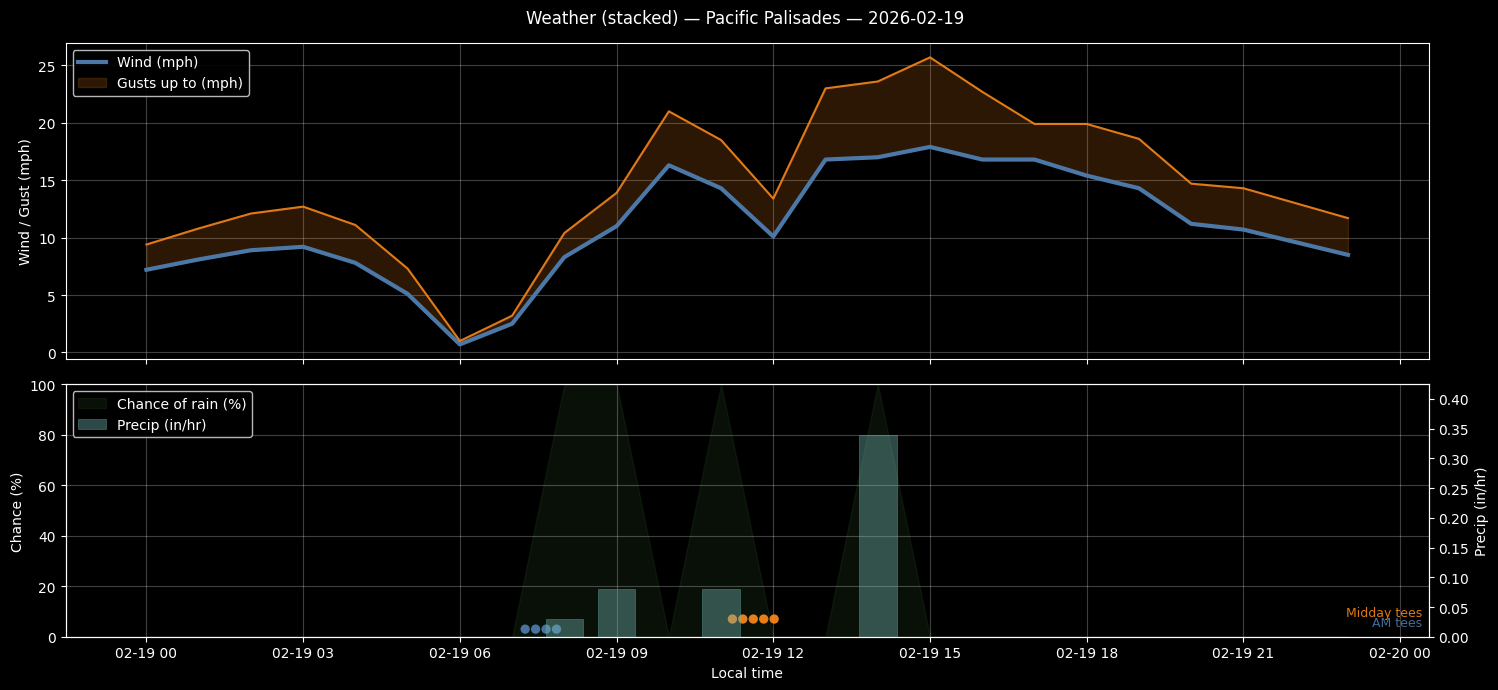

,tee_time_pst,group
0,2026-02-19 07:15:00,Valimaki / Poston / Hoey
1,2026-02-19 07:27:00,Kitayama / Echavarria / Knapp
2,2026-02-19 07:39:00,McCarty / Vegas / Pendrith
3,2026-02-19 07:51:00,Hoge / Cauley / Schmid
4,2026-02-19 11:13:00,Straka / Hall / Cantlay
5,2026-02-19 11:25:00,Gotterup / Rose / MacIntyre
6,2026-02-19 11:37:00,Scheffler / Schauffele / Si Woo Kim
7,2026-02-19 11:49:00,Min Woo Lee / Spieth / Berger
8,2026-02-19 12:01:00,Campbell / Clark / Penge


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) Hardcoded tee times (EST -> PST already converted, Feb = -3h)
# ============================================================
tee_times = [
    "2026-02-19 07:15",  # 10:15 AM EST
    "2026-02-19 07:27",  # 10:27 AM EST
    "2026-02-19 07:39",  # 10:39 AM EST
    "2026-02-19 07:51",  # 10:51 AM EST
    "2026-02-19 11:13",  # 2:13 PM EST
    "2026-02-19 11:25",  # 2:25 PM EST
    "2026-02-19 11:37",  # 2:37 PM EST
    "2026-02-19 11:49",  # 2:49 PM EST
    "2026-02-19 12:01",  # 3:01 PM EST
]

tee_labels = [
    "Valimaki / Poston / Hoey",
    "Kitayama / Echavarria / Knapp",
    "McCarty / Vegas / Pendrith",
    "Hoge / Cauley / Schmid",
    "Straka / Hall / Cantlay",
    "Gotterup / Rose / MacIntyre",
    "Scheffler / Schauffele / Si Woo Kim",
    "Min Woo Lee / Spieth / Berger",
    "Campbell / Clark / Penge",
]

# Split into two colored lanes (based on your list order)
am_times   = tee_times[:4]   # 7:15–7:51 PST
mid_times  = tee_times[4:]   # 11:13–12:01 PST

# ============================================================
# 2) Helper: plot stacked weather + tee-time dot lanes
# ============================================================
def plot_day_weather_stacked_with_tee_dots(
    dfp: pd.DataFrame,
    day: str,
    *,
    am_tee_times=None,
    mid_tee_times=None,
    show_tee_table=True
):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    # Required numeric cols
    for c in ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]:
        if c not in d.columns:
            raise KeyError(f"Missing '{c}' in dfp. Available: {list(d.columns)}")
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(0, 100)
    precip = d["precip_in"].clip(lower=0)

    # Colors (distinct + readable on dark)
    c_wind = "#4C78A8"   # blue
    c_gust = "#F58518"   # orange
    c_rain = "#54A24B"   # green
    c_prec = "#72B7B2"   # teal

    c_am   = "#4C78A8"   # match wind
    c_mid  = "#F58518"   # match gust

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1.6]}
    )

    # -------------------------
    # Panel 1: Wind + gust band
    # -------------------------
    ax1.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)
    ax1.fill_between(
        x, wind, gust,
        where=(gust >= wind),
        interpolate=True,
        color=c_gust,
        alpha=0.18,
        label="Gusts up to (mph)",
        zorder=4
    )
    ax1.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)
    ax1.set_ylabel("Wind / Gust (mph)")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", framealpha=0.9)

    # -------------------------
    # Panel 2: Chance (%) + precip (in/hr)
    # -------------------------
    ax2.fill_between(x, 0, rain, color=c_rain, alpha=0.10, label="Chance of rain (%)", zorder=1)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Chance (%)")
    ax2.grid(True, alpha=0.25)

    ax2p = ax2.twinx()
    ax2p.bar(
        x, precip,
        width=0.03,                 # hourly timestamps
        color=c_prec,
        alpha=0.40,
        edgecolor=c_prec,
        linewidth=0.6,
        label="Precip (in/hr)",
        zorder=2
    )
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax2p.set_ylim(0, max(0.05, pmax * 1.25))
    ax2p.set_ylabel("Precip (in/hr)")

    # Combined legend for bottom panel
    h2, l2 = ax2.get_legend_handles_labels()
    h2p, l2p = ax2p.get_legend_handles_labels()
    ax2.legend(h2 + h2p, l2 + l2p, loc="upper left", framealpha=0.9)

    # -------------------------
    # Tee-time dots lane (clean)
    # -------------------------
    def _add_tee_dots_lane(ax, times, *, color, y, size=45, alpha=0.95):
        if not times:
            return
        tees = [pd.to_datetime(t) for t in times]
        ax.scatter(
            tees,
            [y] * len(tees),
            transform=ax.get_xaxis_transform(),
            s=size,
            alpha=alpha,
            color=color,
            edgecolors="none",
            zorder=30,
            clip_on=False,
        )

    # Put dots on bottom panel only (cleanest)
    _add_tee_dots_lane(ax2, am_tee_times,  color=c_am,  y=0.03)
    _add_tee_dots_lane(ax2, mid_tee_times, color=c_mid, y=0.07)

    # Tiny lane labels (no wave blocks)
    if am_tee_times:
        ax2.text(0.995, 0.03, "AM tees", transform=ax2.transAxes,
                 ha="right", va="bottom", fontsize=9, alpha=0.9, color=c_am)
    if mid_tee_times:
        ax2.text(0.995, 0.07, "Midday tees", transform=ax2.transAxes,
                 ha="right", va="bottom", fontsize=9, alpha=0.9, color=c_mid)

    # -------------------------
    # Title + layout
    # -------------------------
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    fig.suptitle(f"Weather (stacked){title_loc} — {day}", y=0.98)
    ax2.set_xlabel("Local time")

    plt.tight_layout()
    plt.show()

    # Optional: tee table (where identity belongs)
    if show_tee_table and (am_tee_times or mid_tee_times):
        all_times = (am_tee_times or []) + (mid_tee_times or [])
        # If the user passed a full tee list and labels, show them; otherwise just times
        return pd.DataFrame({"tee_time_local": pd.to_datetime(all_times)}).sort_values("tee_time_local")

# ============================================================
# 3) Call it (assumes dfp exists = your df_hourly cleaned)
# ============================================================
# If you don't already have dfp, uncomment the next lines:
# dfp = df_hourly.copy()
# dfp["dt_local"] = pd.to_datetime(dfp["dt_local"], errors="coerce")

plot_day_weather_stacked_with_tee_dots(
    dfp,
    "2026-02-19",
    am_tee_times=am_times,
    mid_tee_times=mid_times,
    show_tee_table=False
)

# Optional: show tee table with names (recommended)
tee_table = pd.DataFrame(
    {"tee_time_pst": pd.to_datetime(tee_times), "group": tee_labels}
).sort_values("tee_time_pst")
tee_table


In [9]:
# --- One-cell: Genesis field L12 map (Ball Striking vs Short Game) with headshot dots ---

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import base64
from pathlib import Path

FIELDS_XLSX = "/Users/joshmacbook/python_projects/OAD/Data/MST/Fields.xlsx"
ALL_PLAYERS_XLSX = "/Users/joshmacbook/python_projects/OAD/Data/MST/All_players.xlsx"
ROUNDS_CSV  = "/Users/joshmacbook/python_projects/OAD/Data/MST/combined_roundlevel_2024_present.csv"

EVENT_ID = 7
WINDOW = 12

USE_MEDIAN_QUADRANTS = False
IMAGE_SCALE = 0.035
MAX_IMAGES = 140
LABEL_TOP_N = 0
JITTER = 0.0


def load_event_field(fields_path: str, event_id: int) -> pd.DataFrame:
    xls = pd.ExcelFile(fields_path)
    best = None
    for sh in xls.sheet_names:
        df = pd.read_excel(fields_path, sheet_name=sh)
        cols = {c.lower(): c for c in df.columns}
        if "event_id" in cols and ("dg_id" in cols or "player_name" in cols):
            df2 = df.copy()
            df2["event_id"] = pd.to_numeric(df2[cols["event_id"]], errors="coerce")
            if "dg_id" in cols:
                df2["dg_id"] = pd.to_numeric(df2[cols["dg_id"]], errors="coerce")
            if "player_name" in cols:
                df2["player_name"] = df2[cols["player_name"]].astype(str)
            sub = df2[df2["event_id"] == int(event_id)].copy()
            if not sub.empty:
                best = sub
                break
    if best is None or best.empty:
        raise ValueError(f"Could not find event_id={event_id} in any Fields.xlsx sheet.")

    keep = [c for c in ["event_id", "dg_id", "player_name"] if c in best.columns]
    best = best[keep].drop_duplicates().copy()
    if "dg_id" not in best.columns:
        raise ValueError("Field table did not contain dg_id.")

    best = best.dropna(subset=["dg_id"]).copy()
    best["dg_id"] = pd.to_numeric(best["dg_id"], errors="coerce")
    best = best.dropna(subset=["dg_id"]).copy()
    best["dg_id"] = best["dg_id"].astype(int)

    if "player_name" not in best.columns:
        best["player_name"] = best["dg_id"].astype(str)
    return best


def pick_recency_sort(df: pd.DataFrame):
    for c in ["start_date", "date", "round_date", "event_date"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
            return ([c], [False])
    if "event_id" in df.columns and "round_num" in df.columns:
        df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce")
        df["round_num"] = pd.to_numeric(df["round_num"], errors="coerce")
        return (["event_id", "round_num"], [False, False])
    raise ValueError("Need start_date/date/round_date/event_date OR (event_id and round_num).")


def path_to_data_uri(path: str) -> str:
    p = Path(path)
    if not p.exists():
        return ""
    ext = p.suffix.lower().lstrip(".")
    mime = "image/png" if ext == "png" else "image/jpeg"
    enc = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{enc}"


def make_plot_with_headshots(d: pd.DataFrame, x: str, y: str, img_col: str) -> go.Figure:
    fig = go.Figure()

    # Keep ALL plotly tokens literal (no f-strings around %{...})
    hover = (
        "<b>%{customdata[0]}</b><br>"
        "Ball Striking (OTT+APP): %{x:.3f}<br>"
        "Short Game (ARG+PUTT): %{y:.3f}<br>"
        "APP: %{customdata[1]:.3f}<br>"
        "OTT: %{customdata[2]:.3f}<br>"
        "ARG: %{customdata[3]:.3f}<br>"
        "PUTT: %{customdata[4]:.3f}<br>"
        "Rounds L12: %{customdata[5]}<br>"
        "dg_id: %{customdata[6]}"
        "<extra></extra>"
    )

    fig.add_trace(
        go.Scatter(
            x=d[x],
            y=d[y],
            mode="markers",
            marker=dict(size=10, opacity=0.0),
            customdata=np.stack(
                [
                    d["player_name"].astype(str),
                    d[f"sg_app_L{WINDOW}"],
                    d[f"sg_ott_L{WINDOW}"],
                    d[f"sg_arg_L{WINDOW}"],
                    d[f"sg_putt_L{WINDOW}"],
                    d[f"rounds_L{WINDOW}"].fillna(0).astype(int),
                    d["dg_id"].astype(int),
                ],
                axis=1,
            ),
            hovertemplate=hover,
            showlegend=False,
        )
    )

    if LABEL_TOP_N and LABEL_TOP_N > 0:
        top = d.sort_values(x, ascending=False).head(int(LABEL_TOP_N)).copy()
        fig.add_trace(
            go.Scatter(
                x=top[x],
                y=top[y],
                mode="text",
                text=top["player_name"],
                textposition="top center",
                showlegend=False,
                hoverinfo="skip",
            )
        )

    if USE_MEDIAN_QUADRANTS:
        x0 = float(d[x].median())
        y0 = float(d[y].median())
    else:
        x0, y0 = 0.0, 0.0

    fig.add_shape(type="line", x0=x0, x1=x0, y0=float(d[y].min()), y1=float(d[y].max()))
    fig.add_shape(type="line", x0=float(d[x].min()), x1=float(d[x].max()), y0=y0, y1=y0)

    xrange = float(d[x].max() - d[x].min()) if len(d) else 1.0
    yrange = float(d[y].max() - d[y].min()) if len(d) else 1.0
    sizex = xrange * IMAGE_SCALE
    sizey = yrange * IMAGE_SCALE

    d_img = d.dropna(subset=[img_col]).copy()
    d_img[img_col] = d_img[img_col].astype(str).str.strip()
    d_img = d_img[d_img[img_col].str.len() > 3].copy()
    if len(d_img) > MAX_IMAGES:
        d_img = d_img.head(MAX_IMAGES).copy()

    for _, r in d_img.iterrows():
        src = str(r[img_col]).strip()
        if not src:
            continue
        fig.add_layout_image(
            dict(
                source=src,
                xref="x",
                yref="y",
                x=float(r[x]),
                y=float(r[y]),
                xanchor="center",
                yanchor="middle",
                sizex=sizex,
                sizey=sizey,
                sizing="contain",
                opacity=1.0,
                layer="above",
            )
        )

    fig.update_layout(
        title=f"Genesis Invitational Field — Ball Striking vs Short Game (L{WINDOW}) with Headshots",
        xaxis_title=f"Ball Striking = SG OTT + SG APP (L{WINDOW})",
        yaxis_title=f"Short Game = SG ARG + SG PUTT (L{WINDOW})",
        height=780,
        margin=dict(l=45, r=45, t=80, b=45),
    )
    return fig


# ---- build data ----
field = load_event_field(FIELDS_XLSX, EVENT_ID)

rounds = pd.read_csv(ROUNDS_CSV)
rounds["dg_id"] = pd.to_numeric(rounds["dg_id"], errors="coerce")
rounds = rounds.dropna(subset=["dg_id"]).copy()
rounds["dg_id"] = rounds["dg_id"].astype(int)

needed_stats = ["sg_putt", "sg_app", "sg_ott", "sg_arg"]
missing = [s for s in needed_stats if s not in rounds.columns]
if missing:
    raise ValueError(f"Rounds file missing required columns: {missing}")

sort_cols, ascending = pick_recency_sort(rounds)
rounds = rounds.sort_values(["dg_id"] + sort_cols, ascending=[True] + ascending)

tmp = rounds.groupby("dg_id", sort=False).head(WINDOW)

rolling = (
    tmp.groupby("dg_id", sort=False)[needed_stats]
    .mean()
    .add_suffix(f"_L{WINDOW}")
    .reset_index()
)
rolling[f"rounds_L{WINDOW}"] = tmp.groupby("dg_id", sort=False).size().values

ap = pd.read_excel(ALL_PLAYERS_XLSX)
ap_cols = {c.lower(): c for c in ap.columns}
ap = ap.rename(columns={ap_cols["dg_id"]: "dg_id", ap_cols["image"]: "image"}).copy()
ap["dg_id"] = pd.to_numeric(ap["dg_id"], errors="coerce")
ap = ap.dropna(subset=["dg_id"]).copy()
ap["dg_id"] = ap["dg_id"].astype(int)
ap["image"] = ap["image"].astype(str)

df = (
    field.merge(rolling, on="dg_id", how="left")
         .merge(ap[["dg_id", "image"]], on="dg_id", how="left")
)

df["ball_striking_L12"] = df[f"sg_ott_L{WINDOW}"] + df[f"sg_app_L{WINDOW}"]
df["short_game_L12"]    = df[f"sg_arg_L{WINDOW}"] + df[f"sg_putt_L{WINDOW}"]
df = df.dropna(subset=["ball_striking_L12", "short_game_L12"]).copy()

if JITTER and JITTER > 0:
    rng = np.random.default_rng(7)
    df["ball_striking_L12"] = df["ball_striking_L12"] + rng.normal(0, JITTER, size=len(df))
    df["short_game_L12"] = df["short_game_L12"] + rng.normal(0, JITTER, size=len(df))

df["image_src"] = df["image"].astype(str).str.strip()
mask_local = (df["image_src"].str.len() > 3) & (~df["image_src"].str.lower().str.startswith("http"))
if mask_local.any():
    df.loc[mask_local, "image_src"] = df.loc[mask_local, "image_src"].apply(path_to_data_uri)

fig = make_plot_with_headshots(df, x="ball_striking_L12", y="short_game_L12", img_col="image_src")
fig.show()


In [18]:
# =========================
# Plot (cleaner + more premium)
# =========================

# --- ranks + better hover payload ---
df = df.copy()
df["fit_rank"] = np.arange(1, len(df) + 1)
df = df.copy()
df["x_plot"] = df["ball_striking"].clip(-AX_CAP, AX_CAP)
df["y_plot"] = df["short_game"].clip(-AX_CAP, AX_CAP)

# label positioning: push labels outward by quadrant to reduce collisions
def _label_pos(x, y):
    if pd.isna(x) or pd.isna(y):
        return "top center"
    if x >= 0 and y >= 0:
        return "top right"
    if x < 0 and y >= 0:
        return "top left"
    if x < 0 and y < 0:
        return "bottom left"
    return "bottom right"

df["label_pos"] = [
    _label_pos(x, y) for x, y in zip(df["ball_striking"].values, df["short_game"].values)
]

# split groups
base = df[~df["is_ring"]].copy()
top  = df[df["is_ring"]].copy()

# build richer customdata for hover
hover_cols = [
    "player_name", "fit_rank", "fit_score",
    "ball_striking", "short_game",
    "z_OTT", "z_APP", "z_ARG", "z_PUTT",
    f"n_rounds_L{WINDOW}",
]
for c in hover_cols:
    if c not in df.columns:
        df[c] = np.nan

def _customdata(frame):
    return np.stack([frame[c].values for c in hover_cols], axis=1)

HOVER_TMPL = (
    "<b>%{customdata[0]}</b>  (#%{customdata[1]})<br><br>"
    "Fit score: <b>%{customdata[2]:.2f}</b><br>"
    "Ball Striking: %{customdata[3]:.2f}<br>"
    "Short Game: %{customdata[4]:.2f}<br><br>"
    "z_OTT: %{customdata[5]:.2f} &nbsp;&nbsp; z_APP: %{customdata[6]:.2f}<br>"
    "z_ARG: %{customdata[7]:.2f} &nbsp;&nbsp; z_PUTT: %{customdata[8]:.2f}<br>"
    f"Rounds L{WINDOW}: %{{customdata[9]}}<extra></extra>"
)

fig = go.Figure()

base = df[~df["is_ring"]].copy()
top  = df[df["is_ring"]].copy()

# Base cloud: tiny, consistent, no gradients/contours
fig.add_trace(
    go.Scatter(
        x=base["x_plot"],
        y=base["y_plot"],
        mode="markers",
        marker=dict(size=6, color="rgba(235,235,235,0.22)"),
        customdata=np.stack(
            [base["player_name"], base["fit_score"], base[f"n_rounds_L{WINDOW}"]], axis=1
        ),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Fit: %{customdata[1]:.2f}<br>"
            f"Rounds L{WINDOW}: %{{customdata[2]}}"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

# Top fits: hollow rings (no fill), slightly larger
fig.add_trace(
    go.Scatter(
        x=top["x_plot"],
        y=top["y_plot"],
        mode="markers",
        marker=dict(
            size=14,
            symbol="circle-open",
            line=dict(width=3, color="rgba(245,245,245,0.95)"),
        ),
        customdata=np.stack(
            [top["player_name"], top["fit_score"], top[f"n_rounds_L{WINDOW}"]], axis=1
        ),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Fit: %{customdata[1]:.2f}<br>"
            f"Rounds L{WINDOW}: %{{customdata[2]}}"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

# Crosshairs (subtle)
fig.add_shape(type="line", x0=-AX_CAP, x1=AX_CAP, y0=0, y1=0,
              line=dict(width=1, color="rgba(255,255,255,0.10)"))
fig.add_shape(type="line", x0=0, x1=0, y0=-AX_CAP, y1=AX_CAP,
              line=dict(width=1, color="rgba(255,255,255,0.10)"))

# Course arrow (muted; label removed because it clutters)
fig.add_annotation(
    x=ax2, y=ay2,
    ax=0, ay=0,
    xref="x", yref="y",
    axref="x", ayref="y",
    showarrow=True,
    arrowhead=3,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="rgba(200,255,220,0.70)",
    text="",
)

# Controlled labels using annotations (NOT scatter text)
lab = top.head(LABEL_TOP_N).copy()
lab = lab.sort_values(["y_plot", "x_plot"], ascending=[False, False]).reset_index(drop=True)

for i, r in lab.iterrows():
    x = float(r["x_plot"])
    y = float(r["y_plot"])

    # stagger labels to avoid overlap; alternate left/right nudges
    xshift = 10 if (i % 2 == 0) else -10
    yshift = 18 + i * 10

    fig.add_annotation(
        x=x, y=y,
        xref="x", yref="y",
        text=str(r["player_name"]),
        showarrow=False,
        xshift=xshift,
        yshift=yshift,
        font=dict(size=12, color="rgba(245,245,245,0.95)"),
        align="left" if xshift > 0 else "right",
    )

title = f"Field Map (L{WINDOW}) — {cw['course_name']}"
subtitle = f"Ring = top {TOP_RING_N} course fits"

fig.update_layout(
    title=dict(text=f"{title}<br><span style='font-size:13px;color:rgba(235,235,235,0.55)'>{subtitle}</span>", x=0.02),
    paper_bgcolor="rgba(10,12,16,1)",
    plot_bgcolor="rgba(10,12,16,1)",
    margin=dict(l=60, r=30, t=85, b=55),
    font=dict(color="rgba(235,235,235,0.88)", size=12),
    height=560,
    showlegend=False,
)

fig.update_xaxes(
    title_text="Ball Striking",
    range=[-AX_CAP, AX_CAP],
    zeroline=False,
    showline=False,
    gridcolor="rgba(255,255,255,0.04)",
    tickcolor="rgba(255,255,255,0.18)",
)
fig.update_yaxes(
    title_text="Short Game",
    range=[-AX_CAP, AX_CAP],
    zeroline=False,
    showline=False,
    gridcolor="rgba(255,255,255,0.04)",
    tickcolor="rgba(255,255,255,0.18)",
    scaleanchor="x",
    scaleratio=1,
)

fig.show()
